In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

2026-04-30 12:08:26.917414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [2]:
# generate dataset
num_curve=10000
A = np.random.uniform(0.5,1.5,size=(num_curve,1))
w = np.random.uniform(0.5,2,size=(num_curve,1))
phi = np.random.uniform(0,2*np.pi,size=(num_curve,1))

N = 100
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [3]:
# generate noisy data
sigma = 0.2
err = np.random.normal(loc=0, scale=sigma, size=clean_curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

Plot examples showing the clean and noisy curve.

Text(0.5, 1.0, 'Noisy Signals')

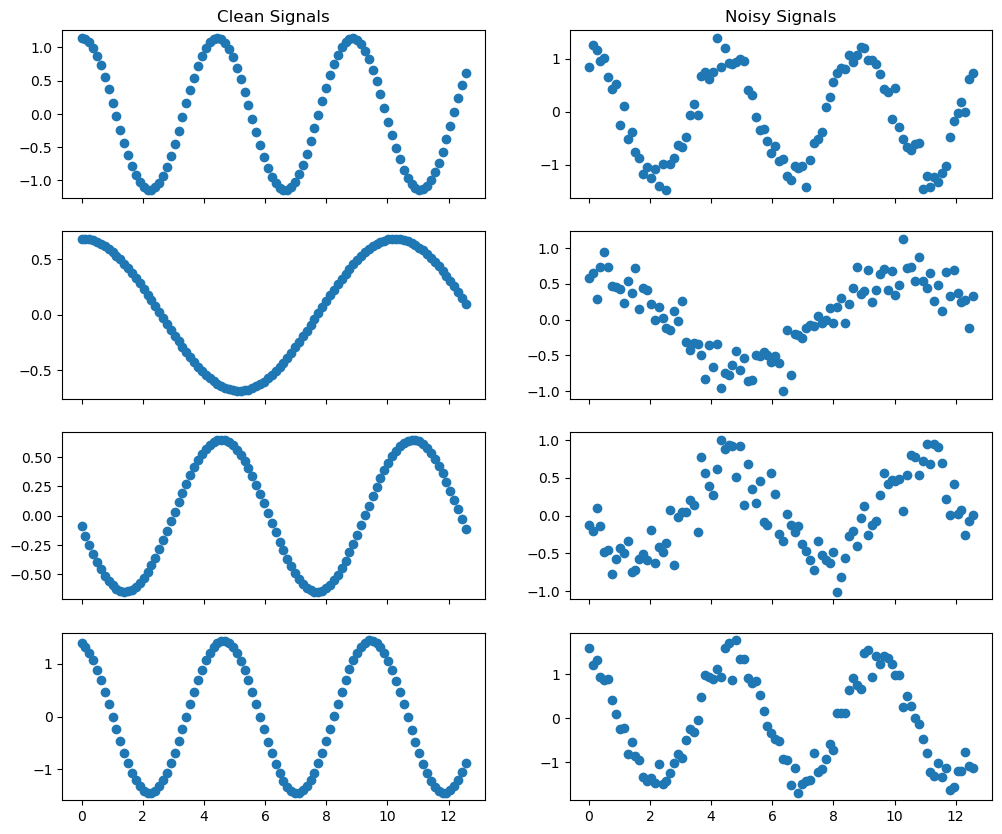

In [4]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 2, figsize=(12, 10),sharex=True)
axes[0,0].scatter(t, clean_curve[3])
axes[0,1].scatter(t, noisy_curve[3])

axes[1,0].scatter(t, clean_curve[489])
axes[1,1].scatter(t, noisy_curve[489])

axes[2,0].scatter(t, clean_curve[1864])
axes[2,1].scatter(t, noisy_curve[1864])

axes[3,0].scatter(t, clean_curve[9999])
axes[3,1].scatter(t, noisy_curve[9999])

axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
#need to figure out how to label axes: all at once or just one set?

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [5]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [6]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [7]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3566 - val_loss: 0.1288
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0705 - val_loss: 0.0401
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0245 - val_loss: 0.0179
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 - val_loss: 0.0146
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0128 - val_loss: 0.0121
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0106 - val_loss: 0.0100
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0090 - val_loss: 0.0091
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0081 - val_loss: 0.0081
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0075 - val_loss: 0.0076
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0071 - val_loss: 0.0074
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0067
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - val_lo

Plot the training and validation loss curves.

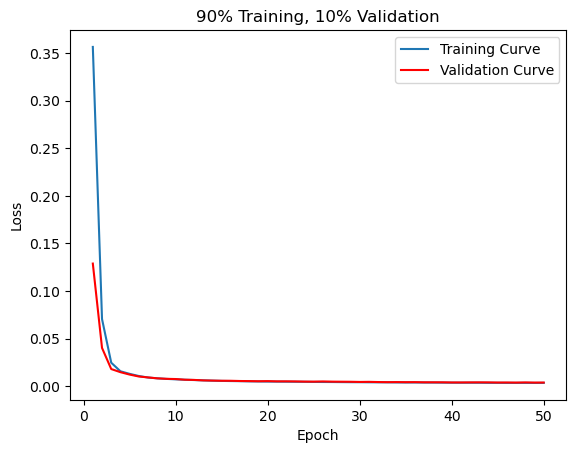

In [8]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [9]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
reconstructed_y.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


(4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

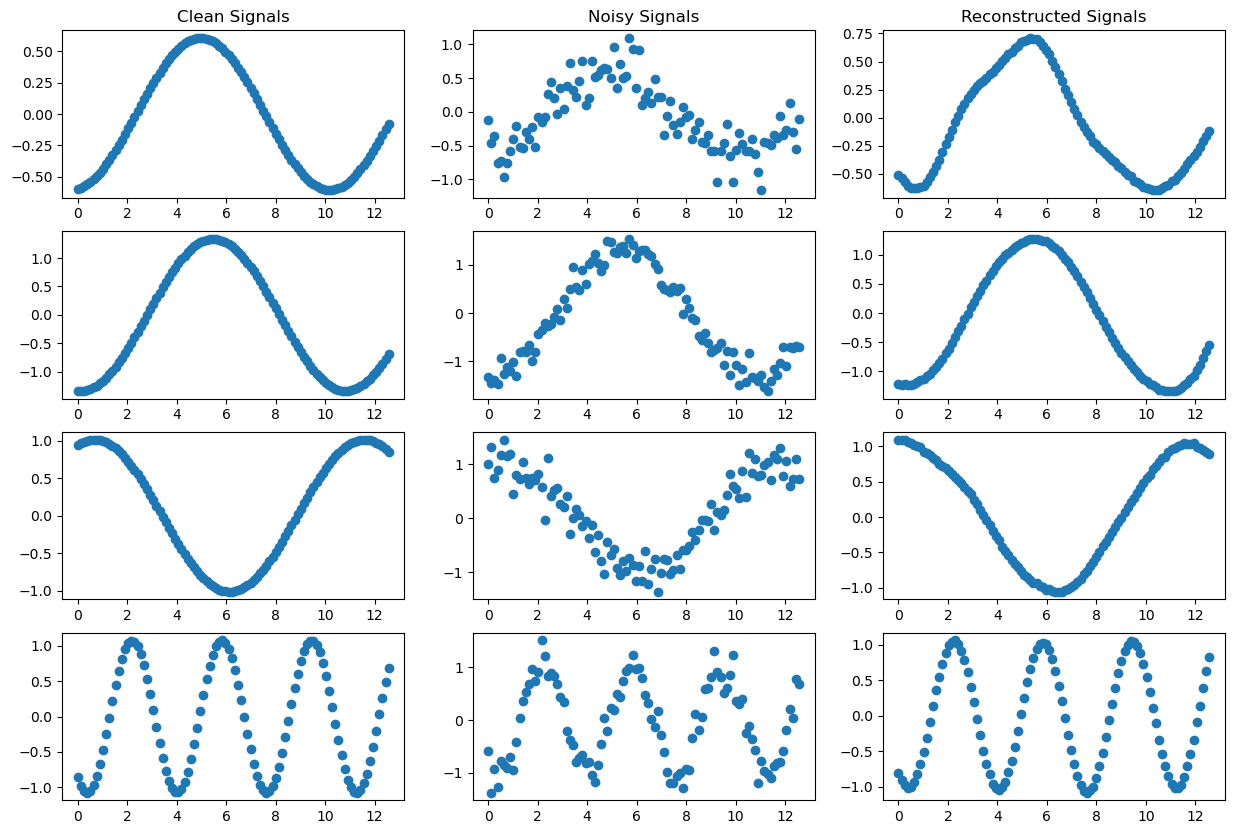

In [10]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
#need to figure out how to label axes: all at once or just one set?
plt.show()

# Parameter Exploration
Investigate how performance changes when modifying the following parameters. For each experiment, provide plots of training and validation loss vs. epochs. Also report the architecture and comment on whether training converges and whether you observe overfitting.

## Training data size 
- 90% training , 10% validation (baseline)
- 60% training , 40% validation
- 30% training , 70% validation
  
Discuss the effect on validation MSE and overfitting.

In [11]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [13]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3633 - val_loss: 0.1349
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0765 - val_loss: 0.0390
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0258 - val_loss: 0.0169
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0149 - val_loss: 0.0125
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0118 - val_loss: 0.0102
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0099 - val_loss: 0.0088
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087 - val_loss: 0.0081
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0078 - val_loss: 0.0074
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0071 - val_loss: 0.0066
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - val_loss: 0.0063
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 0.0060
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_lo

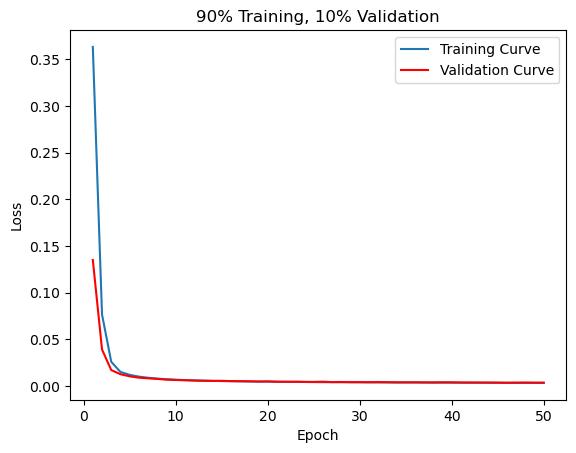

In [14]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [15]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.6) #60% training - must be integer for indexing
train_idx = idx[:training_size] #the 60% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [16]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_lo

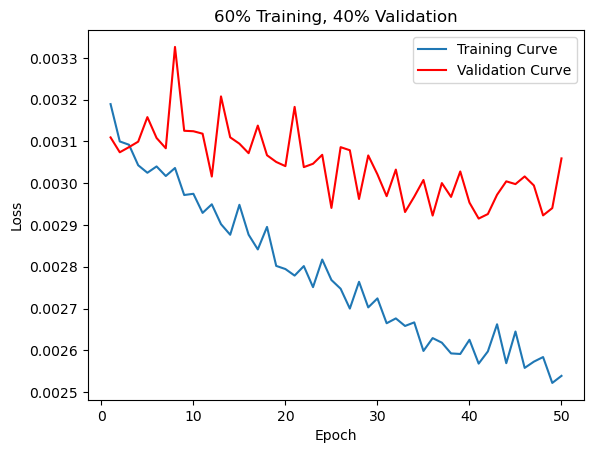

In [17]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("60% Training, 40% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [18]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.3) #70% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [19]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0024 

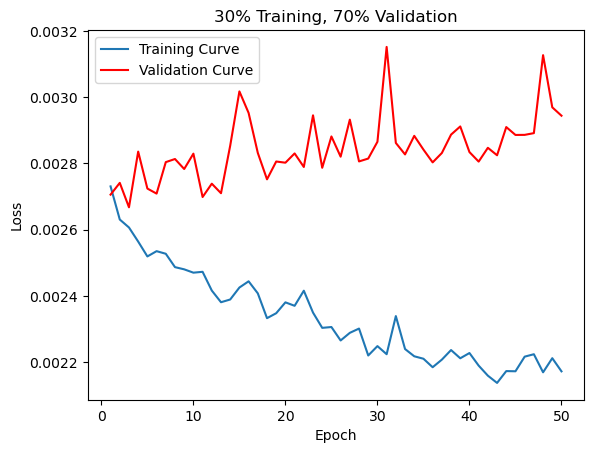

In [20]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("30% Training, 70% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Network architecture
Fix the bottleneck at 4 and experiment with different numbers of layers and neurons.

For example:

Model 1 (Baseline): $100 \rightarrow 64 \rightarrow 4 \rightarrow 64 \rightarrow 100$

Model 2 : $100 \rightarrow 80 \rightarrow 40 \rightarrow 4 \rightarrow 40 \rightarrow 80 \rightarrow 100$

Model 3 : $100 \rightarrow 64 \rightarrow 32 \rightarrow 16 \rightarrow 4 \rightarrow 16 \rightarrow 32 \rightarrow 64 \rightarrow 100$

Record the training time and final validation MSE for each architecture.

In [21]:
#Continue using the 90%/10% for this
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [22]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'), 
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),  
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,240 (59.53 KB)

 Trainable params: 15,240 (59.53 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4978 - val_loss: 0.4150
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3355 - val_loss: 0.2488
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2162 - val_loss: 0.1924
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1737 - val_loss: 0.1506
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1298 - val_loss: 0.1099
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1000 - val_loss: 0.0890
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0809 - val_loss: 0.0748
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0688 - val_loss: 0.0672
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0594 - val_loss: 0.0591
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0526 - val_loss: 0.0534
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0478 - val_loss: 0.0466
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0429 - val_lo

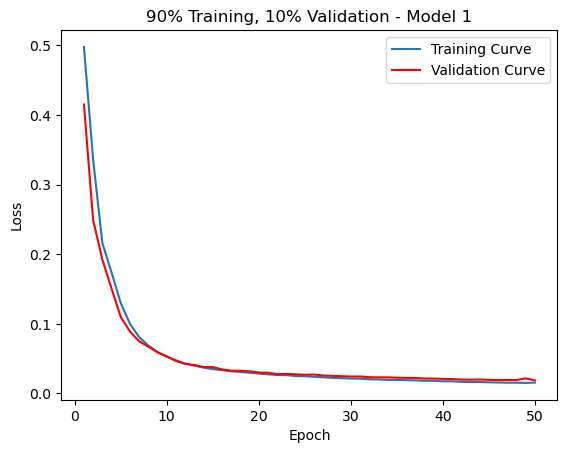

In [24]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [25]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 40)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 80)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │         8,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,064 (90.09 KB)

 Trainable params: 23,064 (90.09 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4007 - val_loss: 0.2309
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1983 - val_loss: 0.1645
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1353 - val_loss: 0.0999
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0840 - val_loss: 0.0668
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0600 - val_loss: 0.0503
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0470 - val_loss: 0.0429
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0394 - val_loss: 0.0369
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0340 - val_loss: 0.0325
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0301 - val_loss: 0.0283
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0270 - val_loss: 0.0258
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0242 - val_loss: 0.0228
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0214 - val_lo

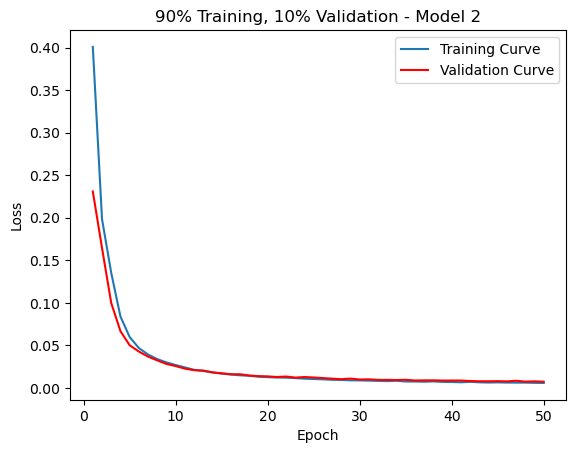

In [27]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [28]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,376 (71.78 KB)

 Trainable params: 18,376 (71.78 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.4757 - val_loss: 0.3530
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2746 - val_loss: 0.2118
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1873 - val_loss: 0.1593
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1370 - val_loss: 0.1102
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0965 - val_loss: 0.0827
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0757 - val_loss: 0.0671
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0636 - val_loss: 0.0580
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0547 - val_loss: 0.0498
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0471 - val_loss: 0.0451
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0420 - val_loss: 0.0408
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0376 - val_loss: 0.0355
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0335 - val_l

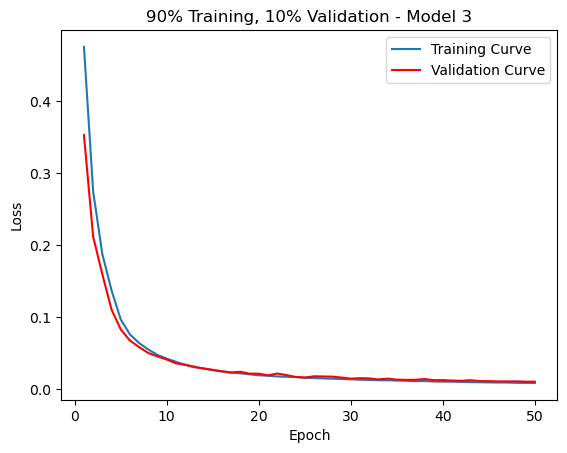

In [30]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Bottleneck Size
Fix the outer architecture (N$ \rightarrow 64 \rightarrow · \rightarrow 64 \rightarrow $N) and vary the bottleneck dimension: 16, 8, 4, 3, 2, 1. Determine the smallest bottleneck size that still reconstructs the signal accurately.

In [31]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [32]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3805 - val_loss: 0.1249
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0545 - val_loss: 0.0247
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0201 - val_loss: 0.0172
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0158 - val_loss: 0.0145
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0133 - val_loss: 0.0124
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0111 - val_loss: 0.0104
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0085 - val_loss: 0.0086
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079 - val_loss: 0.0081
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 - val_loss: 0.0078
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - val_loss: 0.0071
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_lo

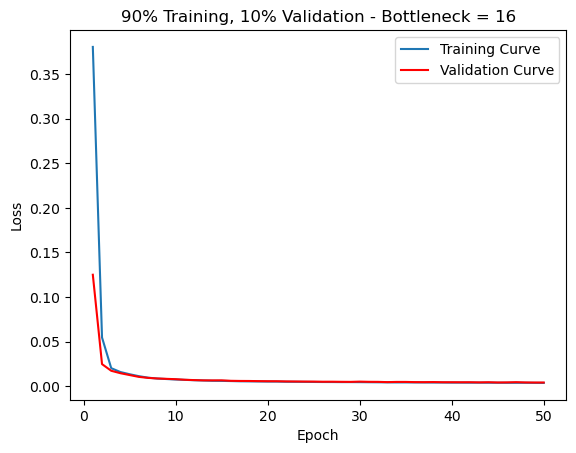

In [34]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 16")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


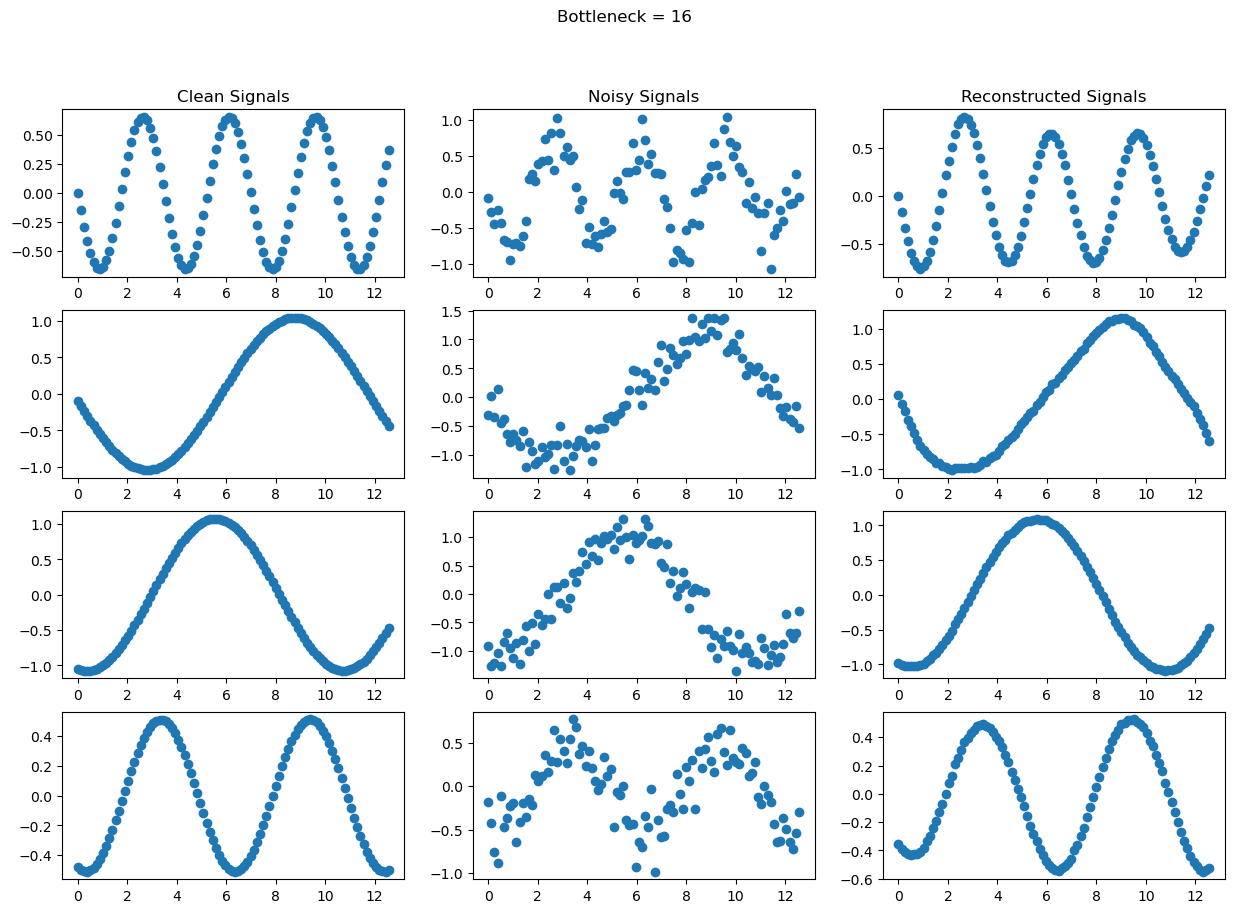

In [35]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 16')

#need to figure out how to label axes: all at once or just one set?
plt.show()

In [36]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(8, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,060 (54.92 KB)

 Trainable params: 14,060 (54.92 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3959 - val_loss: 0.1530
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0834 - val_loss: 0.0531
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0427 - val_loss: 0.0344
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0306 - val_loss: 0.0249
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0212 - val_loss: 0.0181
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0168 - val_loss: 0.0159
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0148 - val_loss: 0.0147
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0138 - val_loss: 0.0139
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0132 - val_loss: 0.0131
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0124 - val_loss: 0.0125
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0121 - val_loss: 0.0122
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0117 - val_lo

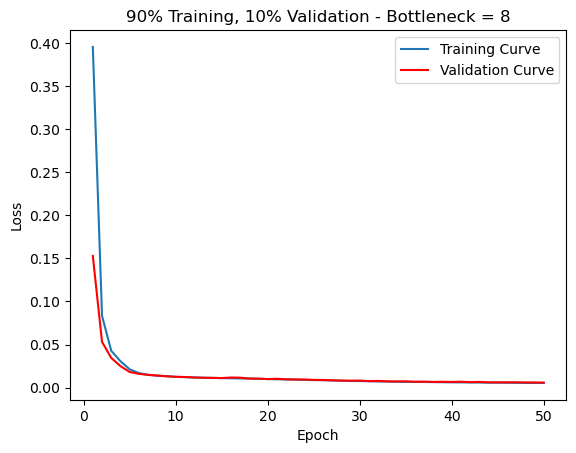

In [38]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 8")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


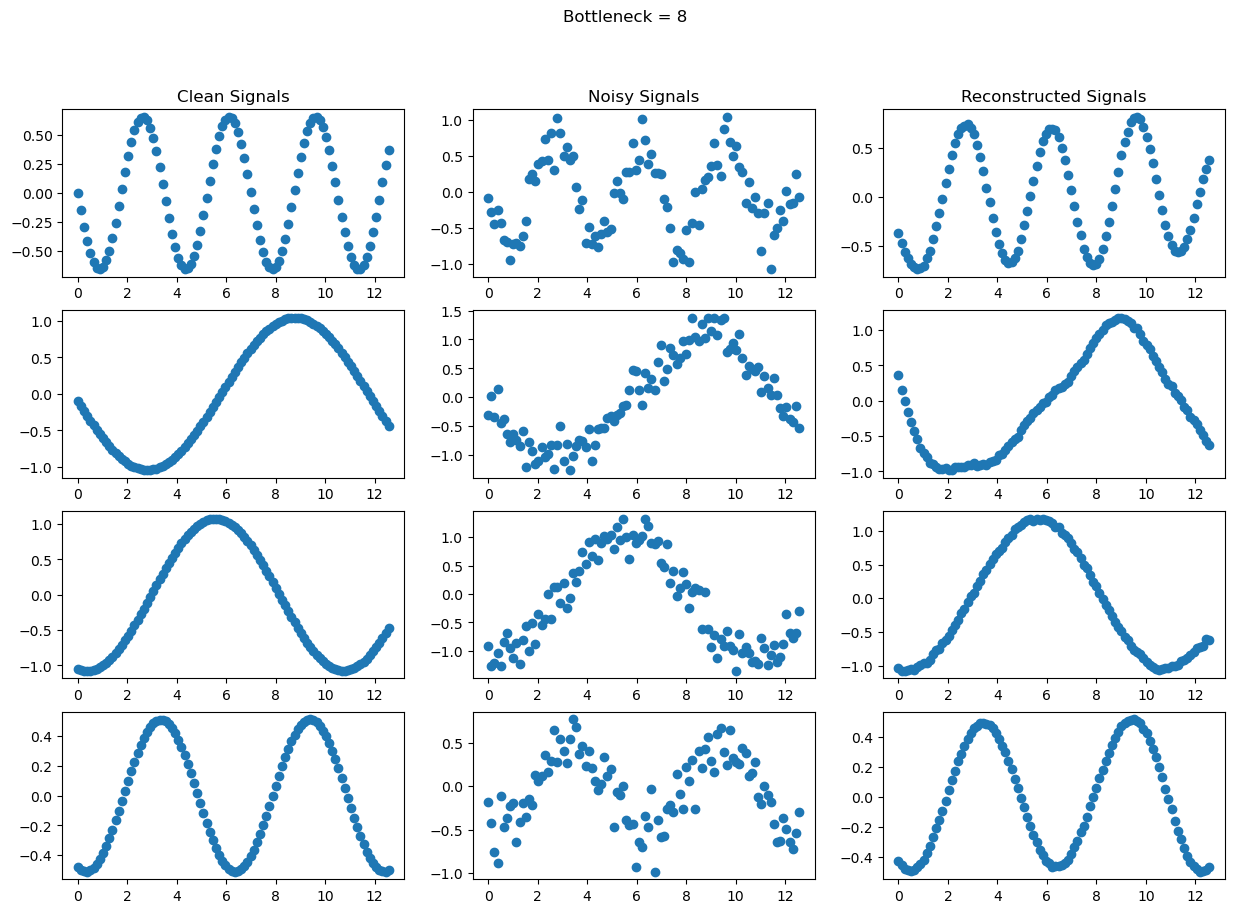

In [39]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 8')

#need to figure out how to label axes: all at once or just one set?
plt.show()

In [40]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,544 (52.91 KB)

 Trainable params: 13,544 (52.91 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4501 - val_loss: 0.3069
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2430 - val_loss: 0.2052
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1777 - val_loss: 0.1560
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1358 - val_loss: 0.1208
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1082 - val_loss: 0.0976
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0875 - val_loss: 0.0777
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0729 - val_loss: 0.0662
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0640 - val_loss: 0.0571
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0571 - val_loss: 0.0515
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0525 - val_loss: 0.0469
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0490 - val_loss: 0.0440
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0461 - val_lo

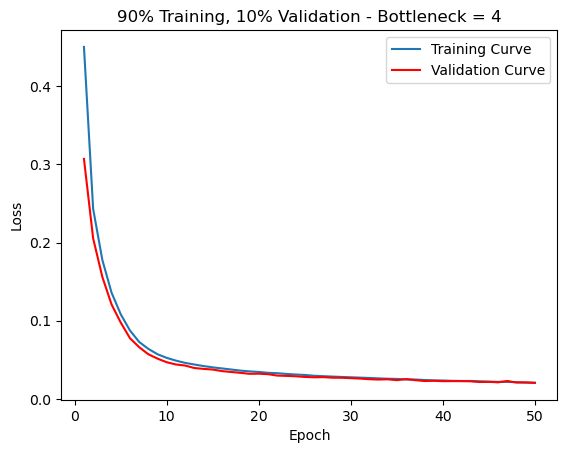

In [42]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 4")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


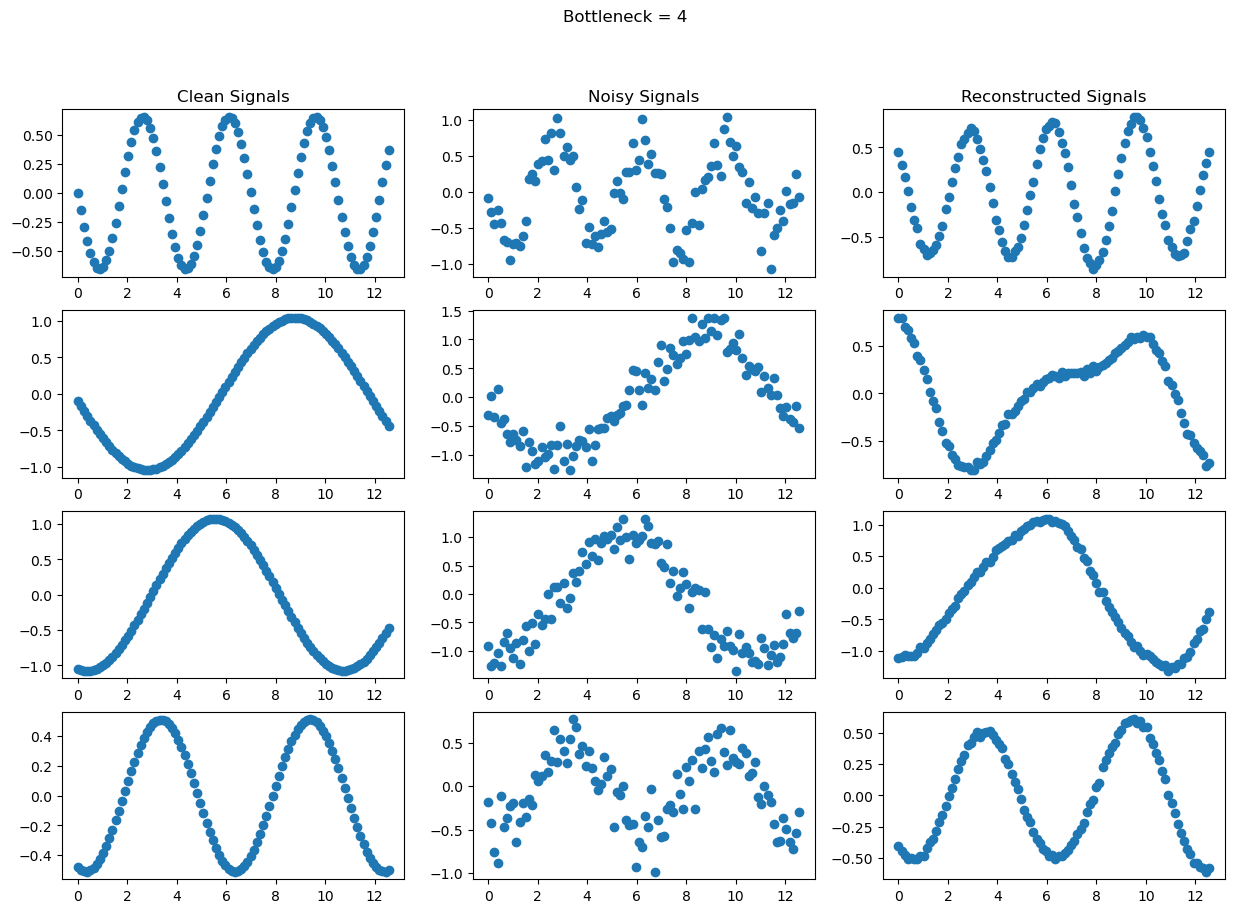

In [43]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 4')
#need to figure out how to label axes: all at once or just one set?
plt.show()

In [44]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(3, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,415 (52.40 KB)

 Trainable params: 13,415 (52.40 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4684 - val_loss: 0.3610
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3209 - val_loss: 0.2978
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2845 - val_loss: 0.2674
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2485 - val_loss: 0.2295
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2098 - val_loss: 0.1896
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1772 - val_loss: 0.1615
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1535 - val_loss: 0.1438
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1353 - val_loss: 0.1282
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1221 - val_loss: 0.1192
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1120 - val_loss: 0.1134
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1049 - val_loss: 0.1087
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0990 - val_lo

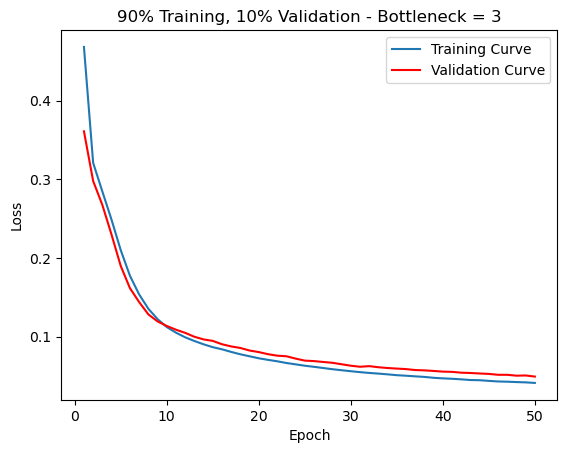

In [46]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


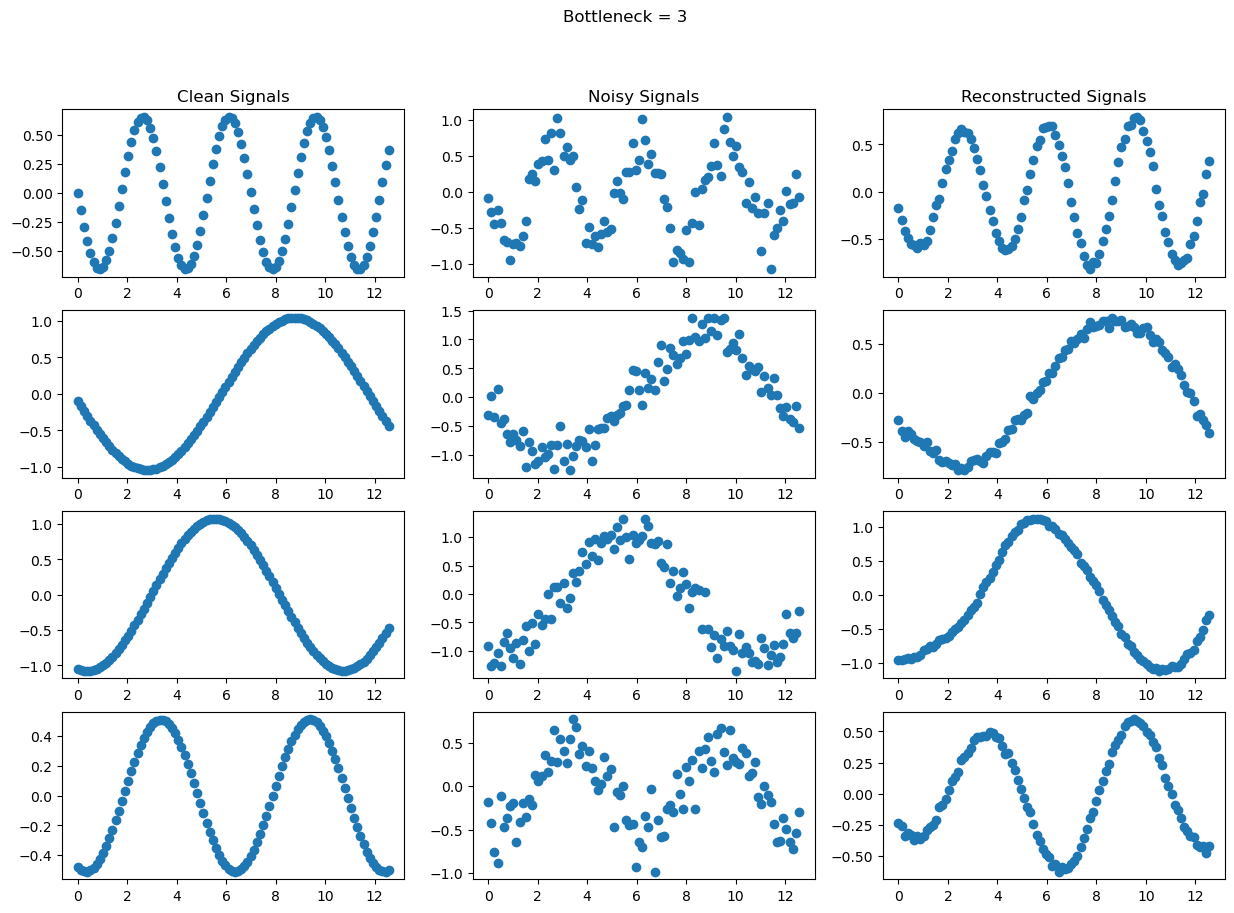

In [47]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 3')
#need to figure out how to label axes: all at once or just one set?
plt.show()

In [48]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(2, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,286 (51.90 KB)

 Trainable params: 13,286 (51.90 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4901 - val_loss: 0.4112
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3983 - val_loss: 0.3759
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3764 - val_loss: 0.3669
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3631 - val_loss: 0.3533
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3442 - val_loss: 0.3333
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3175 - val_loss: 0.3097
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2956 - val_loss: 0.2954
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2835 - val_loss: 0.2850
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2737 - val_loss: 0.2752
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2657 - val_loss: 0.2677
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2590 - val_loss: 0.2631
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2548 - val_lo

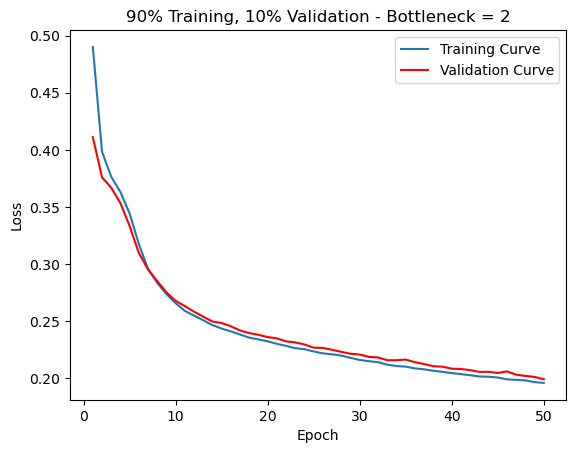

In [50]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


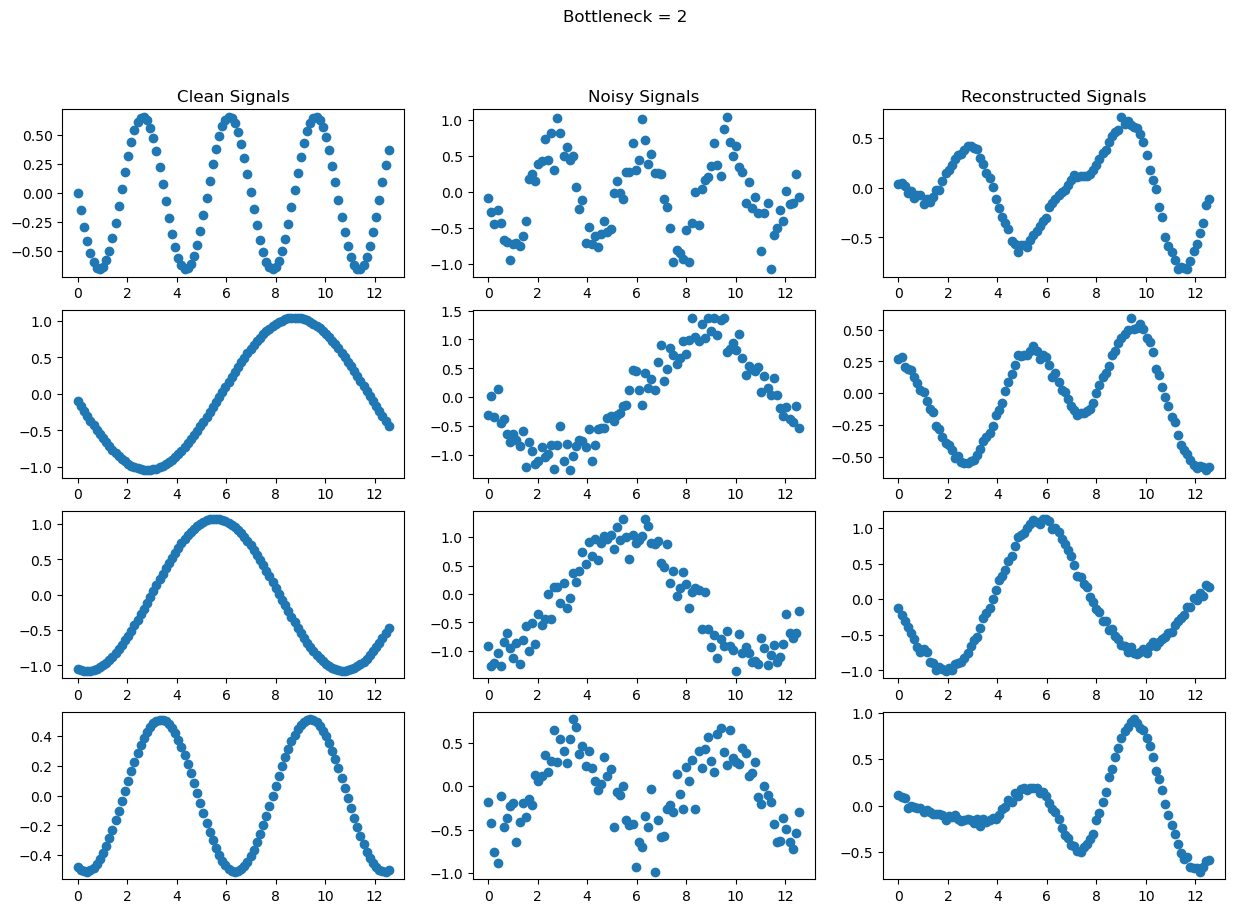

In [51]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 2')
#need to figure out how to label axes: all at once or just one set?
plt.show()

In [52]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(1, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.39 KB)

 Trainable params: 13,157 (51.39 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5093 - val_loss: 0.4820
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4859 - val_loss: 0.4736
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4785 - val_loss: 0.4676
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4734 - val_loss: 0.4633
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4695 - val_loss: 0.4602
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4664 - val_loss: 0.4571
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4634 - val_loss: 0.4545
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4602 - val_loss: 0.4511
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4560 - val_loss: 0.4457
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4501 - val_loss: 0.4404
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4454 - val_loss: 0.4373
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4421 - val_lo

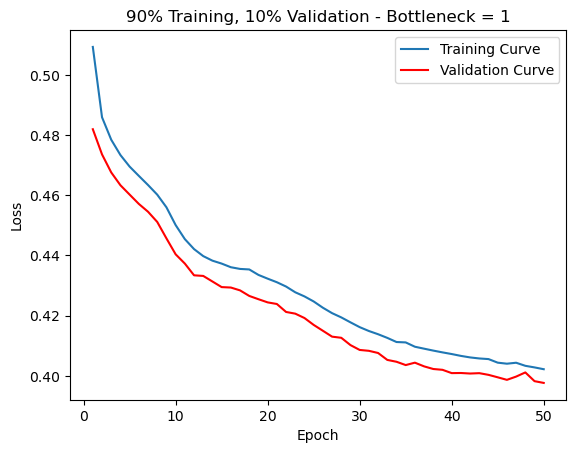

In [54]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


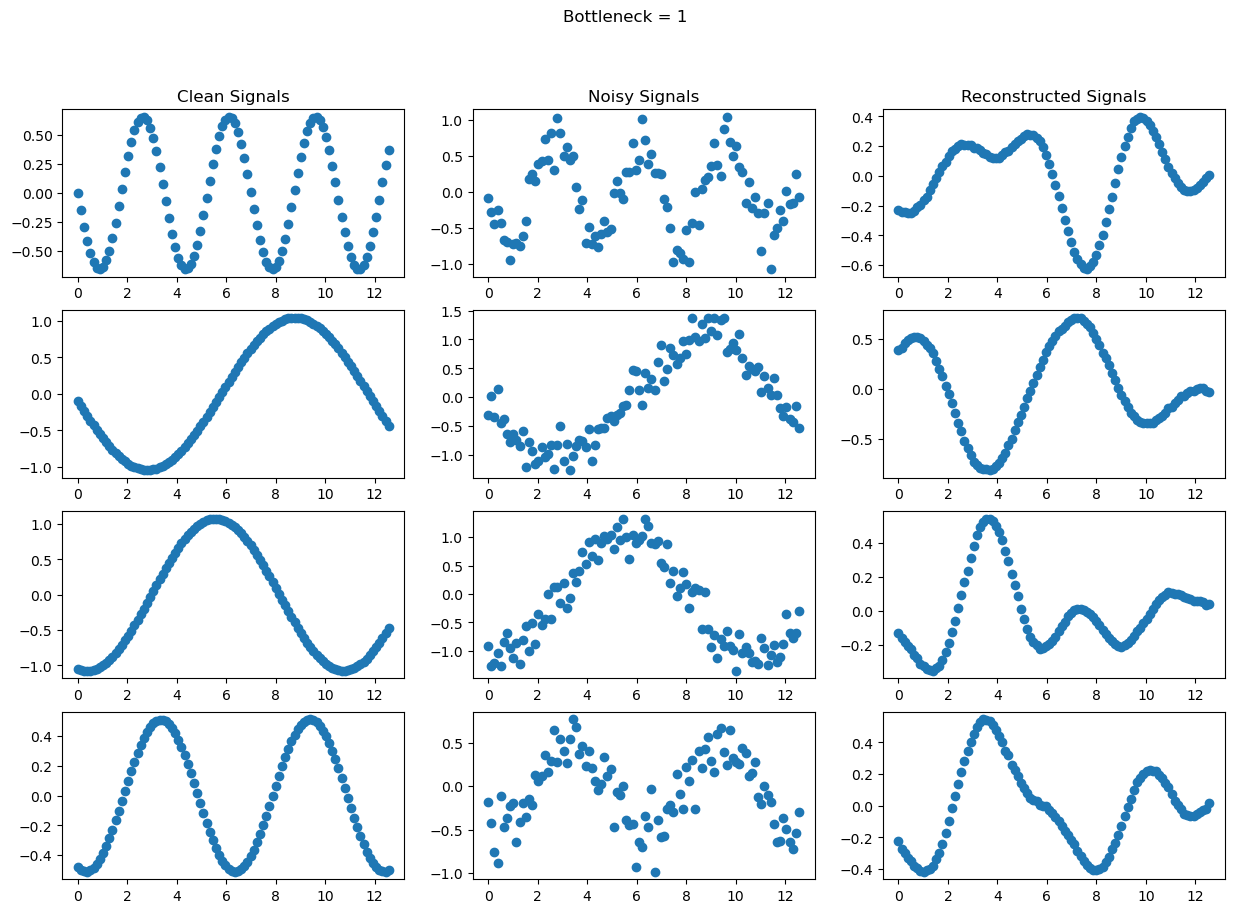

In [55]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 1')
#need to figure out how to label axes: all at once or just one set?
plt.show()

## Noise models
Instead of Gaussian noise, test Laplace noise.

In [56]:
# generate dataset
num_curve=10000
A = np.random.uniform(0.5,1.5,size=(num_curve,1))
w = np.random.uniform(0.5,2,size=(num_curve,1))
phi = np.random.uniform(0,2*np.pi,size=(num_curve,1))

N = 100
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

In [57]:
# generate noisy data - Laplace
sigma = 0.2
err = np.random.laplace(loc=0, scale=sigma, size=clean_curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

In [58]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [59]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3820 - val_loss: 0.1397
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0699 - val_loss: 0.0409
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0283 - val_loss: 0.0231
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0199 - val_loss: 0.0189
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0167 - val_loss: 0.0164
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0146 - val_loss: 0.0142
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0129 - val_loss: 0.0129
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0117 - val_loss: 0.0118
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0110 - val_loss: 0.0113
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0103 - val_loss: 0.0108
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0098 - val_loss: 0.0104
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_lo

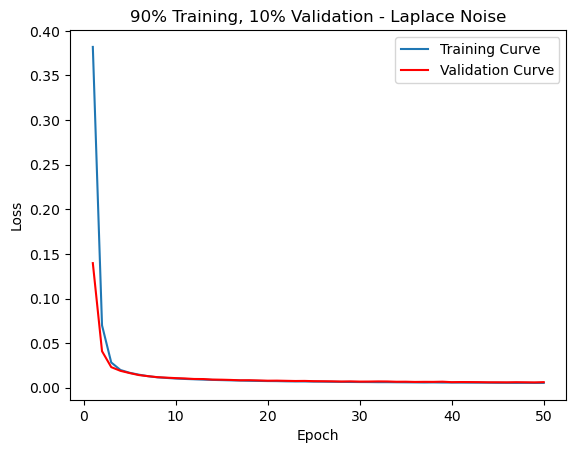

In [61]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Laplace Noise")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


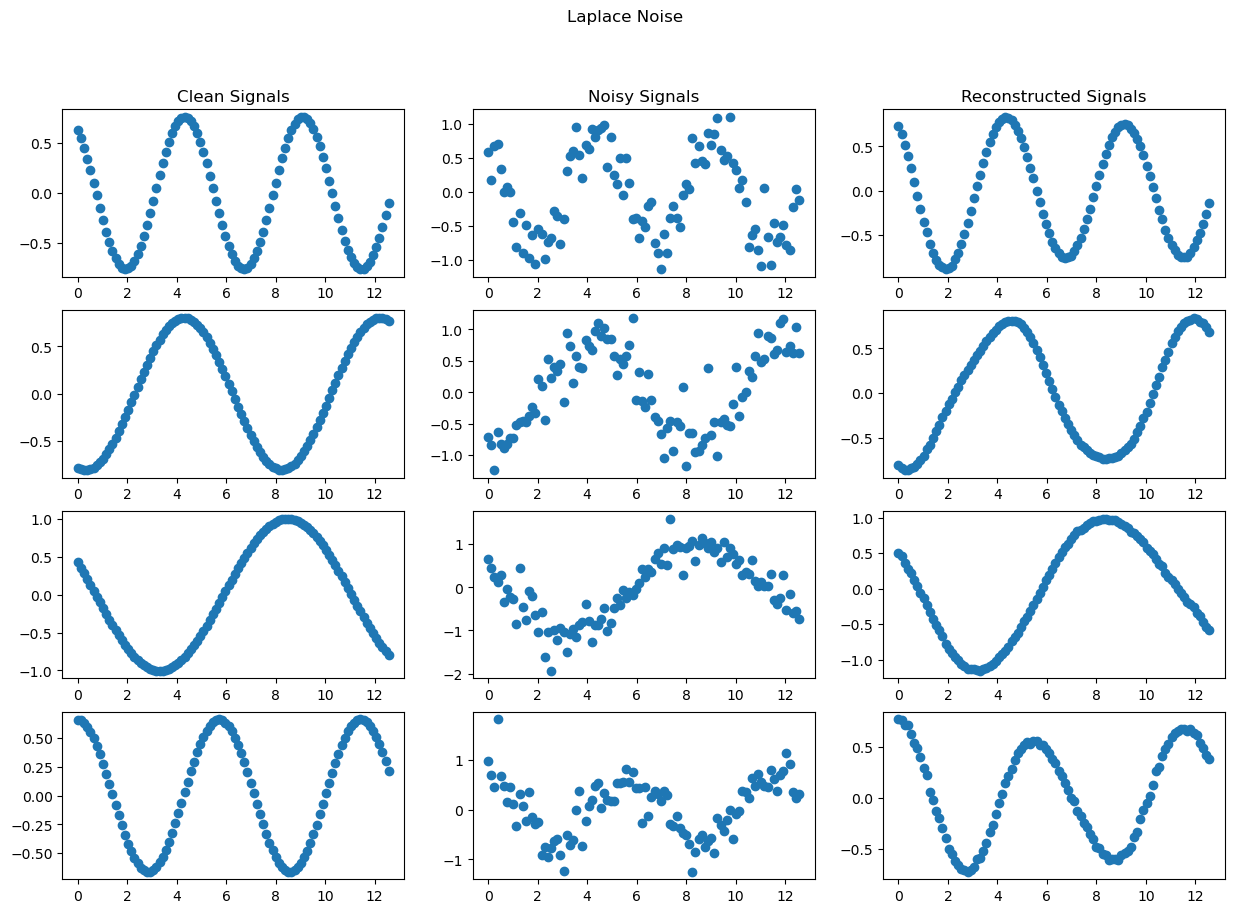

In [62]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)

# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle("Laplace Noise")
#need to figure out how to label axes: all at once or just one set?
plt.show()